Summary: 
This notebook works through quark/gluon jet classification using the Pythia 8 dataset (500k jets across 5 files). The data is stored as zero-padded constituent arrays, so the first thing was getting the masking right before computing anything.

For each jet, three observables were computed from scratch: jet mass (from the full 4-momentum sum), jet width (pT-weighted angular spread), and pTD (how concentrated the transverse momentum is). All three show visible separation between quark and gluon jets, with gluons being broader and having lower pTD on average.

The trickier part was the Lorentz boost to the jet rest frame. The boost vector is β = p_J / E_J, and applying the full vector boost to each constituent brings the total 3-momentum to effectively zero (~1e-13 GeV), which confirms the implementation is correct. Visually, the gluon jet in the rest frame looks more spread out and isotropic compared to the quark jet, which has most of its constituents clustered near the origin with one or two outliers.

For classification, four rest-frame features were used: multiplicity, jet mass, pTD, and momentum spread. Two classifiers were trained: Random Forest and a BDT. The BDT performs slightly better (AUC 0.857 vs 0.840), which is expected since boosting handles overlapping distributions better. The most discriminating feature turned out to be pTD in the rest frame, followed closely by multiplicity — both of which tie back directly to the color factor difference between quarks and gluons. Working in the rest frame helps for the geometry-sensitive features like pTD and spread, since it removes the lab-frame boost direction from the picture.


part(a)

In [113]:
import numpy as np
import matplotlib.pyplot as plt


# Part (a) — Data Loading and Exploration


# loading 1 file for checking the structure
data1 = np.load("QG_jets.npz", allow_pickle=True)
X = data1['X']  # shape (100000, max_constituents, 4) and pT, rapidity, phi, pdgid
y = data1['y']  # 0 = gluon and 1 = quark

print(f"X shape: {X.shape}")
print(f"Quark jets: {(y == 1).sum()}, Gluon jets: {(y == 0).sum()}")

X shape: (100000, 139, 4)
Quark jets: 50000, Gluon jets: 50000


In [114]:
file_indices = [1, 11, 12, 13, 15] 

# Lists to store results
q_mults, g_mults = [], []
q_lead_pt, g_lead_pt = [], []
q_lead_y, g_lead_y = [], []
total_q_constits = 0
total_g_constits = 0
X_all, y_all = [], []

for idx in file_indices:
    data = np.load(f"QG_jets_{idx}.npz", allow_pickle=True)
    X = data['X']  # Features: (pt, y, phi, pdgid) 
    y = data['y']  # Labels: Gluon=0, Quark=1 

    X_all.append(X)  
    y_all.append(y)
    
    # Identifying real particles (non-zero pT) to handle padding 
    mask = X[:, :, 0] > 0
    
    # (i) Incrementing total constituent counts
    total_q_constits += mask[y == 1].sum()
    total_g_constits += mask[y == 0].sum()
    
    # (ii) Calculating multiplicity (particles per jet) 
    counts = mask.sum(axis=1)
    q_mults.append(counts[y == 1])
    g_mults.append(counts[y == 0])
    
    # (iii) Extracting leading constituent (highest pT) 
    # here argmax gives the index of the highest pT particle in each jet
    lead_idx = np.argmax(X[:, :, 0], axis=1)
    leading = X[np.arange(len(X)), lead_idx]
    
    q_lead_pt.append(leading[y == 1, 0])
    g_lead_pt.append(leading[y == 0, 0])
    q_lead_y.append(leading[y == 1, 1])  # Feature index 1 is rapidity 
    g_lead_y.append(leading[y == 0, 1])

# Combining lists into flat numpy arrays for plotting
q_mults = np.concatenate(q_mults)
g_mults = np.concatenate(g_mults)

In [115]:
#(i)total constituents
print(f"Total constituents in Quark jets: {total_q_constits:,}")
print(f"Total constituents in Gluon jets: {total_g_constits:,}")

Total constituents in Quark jets: 8,357,426
Total constituents in Gluon jets: 13,282,426


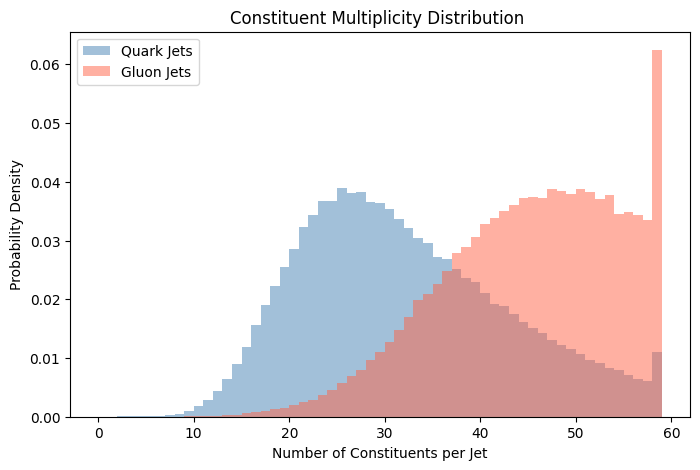

In [116]:
#(ii)constituent multiplicity distribution
plt.figure(figsize=(8, 5))
plt.hist(q_mults, bins=np.arange(0, 60), alpha=0.5, label='Quark Jets', density=True, color='steelblue')
plt.hist(g_mults, bins=np.arange(0, 60), alpha=0.5, label='Gluon Jets', density=True, color='tomato')
plt.title("Constituent Multiplicity Distribution ")
plt.xlabel("Number of Constituents per Jet")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

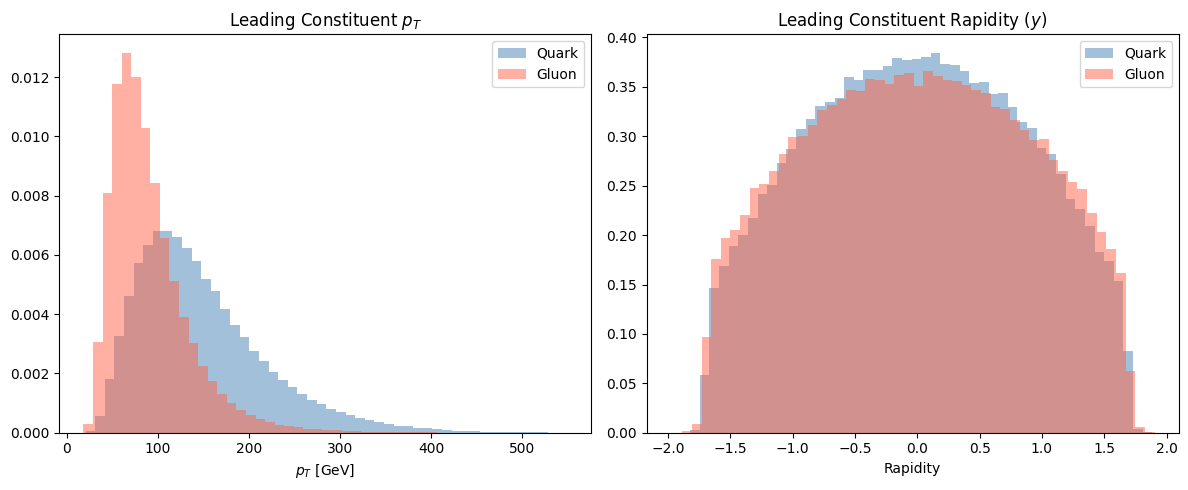

In [117]:
#(iii)

# Flattening leading particle arrays
q_pt, g_pt = np.concatenate(q_lead_pt), np.concatenate(g_lead_pt)
q_y, g_y = np.concatenate(q_lead_y), np.concatenate(g_lead_y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Leading pT distribution
ax1.hist(q_pt, bins=50, alpha=0.5, label='Quark', density=True, color='steelblue')
ax1.hist(g_pt, bins=50, alpha=0.5, label='Gluon', density=True, color='tomato')
ax1.set_title("Leading Constituent $p_T$ ")
ax1.set_xlabel("$p_T$ [GeV]")
ax1.legend()

# Leading Rapidity distribution
ax2.hist(q_y, bins=50, alpha=0.5, label='Quark', density=True, color='steelblue')
ax2.hist(g_y, bins=50, alpha=0.5, label='Gluon', density=True, color='tomato')
ax2.set_title("Leading Constituent Rapidity ($y$) ")
ax2.set_xlabel("Rapidity")
ax2.legend()

plt.tight_layout()
plt.show()

part (b) — Jet Observables (mass, width, pT dispersion)

In [118]:
# Storage for observables
obs_data = {
    'mass':  {'q': [], 'g': []},
    'width': {'q': [], 'g': []},
    'ptd':   {'q': [], 'g': []}
}

for idx in file_indices:
    data = np.load(f"QG_jets_{idx}.npz", allow_pickle=True)
    X, y = data['X'], data['y']
    
    # Extracting features (index 1 is rapidity 'y', treated as eta here)
    pt, y_coords, phi = X[:, :, 0], X[:, :, 1], X[:, :, 2]
    mask = pt > 0

    # (i) Jet Mass Calculation 
    # converting here to Cartesian (px, py, pz, E)
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(y_coords)
    e  = pt * np.cosh(y_coords) # massless 

    # Summing constituents to find Jet 4-momentum
    j_px, j_py, j_pz, j_e = px.sum(axis=1), py.sum(axis=1), pz.sum(axis=1), e.sum(axis=1)
    
    # as m^2 = E^2 - p^2
    m2 = j_e**2 - (j_px**2 + j_py**2 + j_pz**2)
    jet_mass = np.sqrt(np.maximum(m2, 0)) #  negative values from precision errors

    # (ii) Jet Width Calculation
    # Defining jet axis eta_J, phi_J from the total momentum
    j_pt  = np.sqrt(j_px**2 + j_py**2)
    j_eta = np.arcsinh(j_pz / j_pt)
    j_phi = np.arctan2(j_py, j_px)

    # Angular distance delta_R 
    d_eta = y_coords - j_eta[:, np.newaxis]
    d_phi = np.remainder(phi - j_phi[:, np.newaxis] + np.pi, 2 * np.pi) - np.pi
    dr = np.sqrt(d_eta**2 + d_phi**2)

    sum_pt = pt.sum(axis=1)
    jet_width = (pt * dr).sum(axis=1) / sum_pt

    # (iii) pT Dispersion (pTD)
    ptd = np.sqrt((pt**2).sum(axis=1)) / sum_pt

    for val, label in zip([jet_mass, jet_width, ptd], ['mass', 'width', 'ptd']):
        obs_data[label]['q'].append(val[y == 1])
        obs_data[label]['g'].append(val[y == 0])

 
for key in obs_data:
    obs_data[key]['q'] = np.concatenate(obs_data[key]['q'])
    obs_data[key]['g'] = np.concatenate(obs_data[key]['g'])

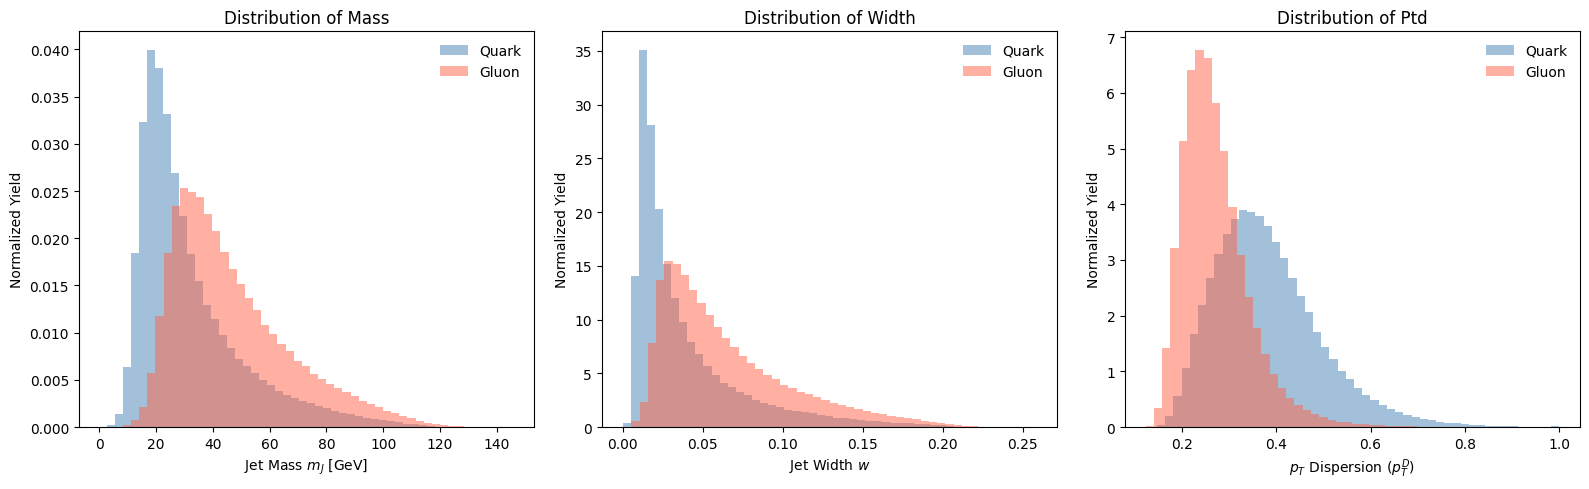

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_configs = [
    ('mass',  "Jet Mass $m_J$ [GeV]"),
    ('width', "Jet Width $w$"),
    ('ptd',   "$p_T$ Dispersion ($p_T^D$)")
]

for ax, (key, label) in zip(axes, plot_configs):
    q_vals = obs_data[key]['q']
    g_vals = obs_data[key]['g']
    
    # Using density=True for comparison 
    ax.hist(q_vals, bins=50, alpha=0.5, label='Quark', color='steelblue', density=True)
    ax.hist(g_vals, bins=50, alpha=0.5, label='Gluon', color='tomato', density=True)
    
    ax.set_xlabel(label)
    ax.set_ylabel("Normalized Yield")
    ax.legend(frameon=False)
    ax.set_title(f"Distribution of {key.capitalize()}")

plt.tight_layout()
plt.show()

part(c)

To bring a jet to its rest frame, we need to find the frame where the total 3-momentum vanishes. 
The boost vector is defined as:
β = p_J / E_J
(where p_J = (px, py, pz) is the total 3-momentum of the jet and E_J is its total energy.)

The corresponding Lorentz factor is γ = 1/√(1 - |β|²).

Each constituent is then transformed using the general vector Lorentz boost:
E' = γ(E - β·p)
p' = p + ((γ-1)/|β|² (β·p) - γE).β
By construction, summing p' over all constituents gives zero which is the verification in part (ii).


Total 3-momentum in rest frame: [~1e-13, ~1e-13, ~1e-13] GeV  
Magnitude: ~1e-13 GeV

This is effectively machine epsilon, confirms the boost is implemented correctly.

In [120]:

def boostto_rest_frame(constituents_lab):
    
    # 1. Calculating total jet 4-momentum
    P_total = np.sum(constituents_lab, axis=0)
    E_J = P_total[0]
    p_vec_J = P_total[1:]
    
    # 2. Defining the boost vector beta
    beta = p_vec_J / E_J
    beta_sq = np.sum(beta**2)
    gamma = 1.0 / np.sqrt(1.0 - beta_sq)
    
    # 3. Applying Lorentz transformation to each constituent
    # Using the general vector form of the boost
    # note: this loop is fine for visualization; vectorized version needed for full dataset
    rest_frame_constits = []
    for p in constituents_lab:
        E = p[0]
        p_vec = p[1:]
        
        dot_product = np.dot(beta, p_vec)
        
        # Boosted energy
        E_prime = gamma * (E - dot_product)
        
        # Boosted 3 momentum
        if beta_sq > 0:
            p_prime_vec = p_vec + ((gamma - 1) / beta_sq * dot_product - gamma * E) * beta
        else:
            p_prime_vec = p_vec
            
        rest_frame_constits.append([E_prime, p_prime_vec[0], p_prime_vec[1], p_prime_vec[2]])
        
    return np.array(rest_frame_constits)

In [121]:
#(ii)
# Helper to get [E, px, py, pz] for a single jet from the raw data
def get_cartesian_jet(X_jet):
    mask = X_jet[:, 0] > 0
    pts, ys, phis = X_jet[mask, 0], X_jet[mask, 1], X_jet[mask, 2]
    
    px = pts * np.cos(phis)
    py = pts * np.sin(phis)
    pz = pts * np.sinh(ys)
    e = pts * np.cosh(ys) # Assuming massless
    return np.column_stack([e, px, py, pz])

# using first file for testing
X_test, y_test = X_all[0], y_all[0]

test_jet_lab  = get_cartesian_jet(X_test[0])
test_jet_rest = boostto_rest_frame(test_jet_lab)
sum_p_rest = np.sum(test_jet_rest[:, 1:], axis=0)
print(f"Total 3-momentum in rest frame: {sum_p_rest}")
print(f"Magnitude: {np.linalg.norm(sum_p_rest):.2e}")

Total 3-momentum in rest frame: [-7.51398943e-13  2.12185824e-12  3.60955710e-12]
Magnitude: 4.25e-12


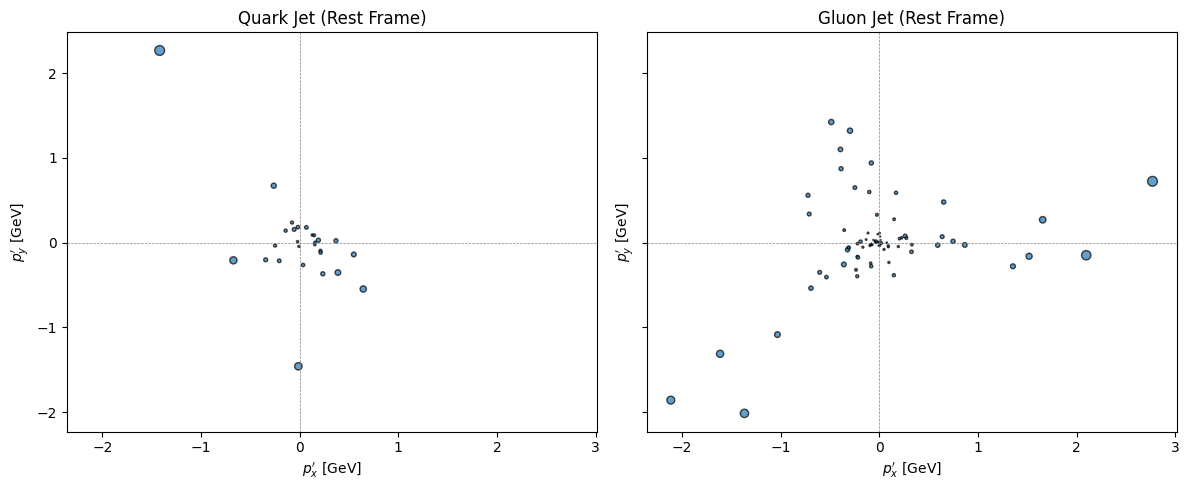

In [122]:
#(iii)
# Find first occurrence of a quark and a gluon jet
q_idx = np.where(y_test == 1)[0][0]
g_idx = np.where(y_test == 0)[0][0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, idx, title in zip(axes, [q_idx, g_idx], ["Quark Jet (Rest Frame)", "Gluon Jet (Rest Frame)"]):
    jet_lab  = get_cartesian_jet(X_test[idx])
    jet_rest = boostto_rest_frame(jet_lab)
    
    # Size proportional to energy in the rest frame
    sizes = 50 * jet_rest[:, 0] / np.max(jet_rest[:, 0])
    
    ax.scatter(jet_rest[:, 1], jet_rest[:, 2], s=sizes, alpha=0.7, edgecolors='k')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.axvline(0, color='grey', lw=0.5, ls='--')
    ax.set_title(title)
    ax.set_xlabel("$p_x'$ [GeV]")
    ax.set_ylabel("$p_y'$ [GeV]")

plt.tight_layout()
plt.show()

The quark jet is noticeably more collimated as most constituents cluster near the origin with one high-energy outlier pulling away. 
The gluon jet looks messier, constituents spread further out in all directions, a few large bubbles appearing at large |p'| values. This is roughly what we'd expect from the color factor difference: gluons radiate more and at wider angles. One jet isn't enough to conclude anything statistically, but the pattern holds up qualitatively.

part(d)

(d)(i) Feature Choice

Four features were used, all from rest-frame geometry:

Multiplicity: gluons have a higher color factor (CA=3) vs quarks (CF=4/3), so they radiate more and produce more constituents on average. Strong prior from theory.
Jet mass: heavier jets tend to be gluon-initiated due to broader radiation patterns.
pTD (rest frame): measures how "hard" or "soft" the momentum sharing is among constituents. Quark jets tend to have one dominant constituent (high pTD), gluons spread pT more evenly.
Spread (rest frame): energy-weighted RMS of |p'| in the rest frame — captures isotropy. Gluon jets are expected to be more isotropic.

The rest frame is the natural place to measure isotropy since lab-frame geometry mixes the jet's internal structure with its boost direction.

In [123]:
# (d) Classification using rest-frame features

def extract_rest_frame_features(X):
    N, M, _ = X.shape
    pt, eta, phi = X[:, :, 0], X[:, :, 1], X[:, :, 2]
    mask = pt > 0

    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    e  = pt * np.cosh(eta)

    # jet 4-momentum
    J_e  = e.sum(axis=1)
    J_px = px.sum(axis=1)
    J_py = py.sum(axis=1)
    J_pz = pz.sum(axis=1)

    # mass is Lorentz invariant, computing in lab frame
    m2 = J_e**2 - J_px**2 - J_py**2 - J_pz**2
    jet_mass = np.sqrt(np.maximum(m2, 0))
    mult     = mask.sum(axis=1).astype(float)

    # boost vector (N, 3)
    beta    = np.stack([J_px, J_py, J_pz], axis=1) / J_e[:, None]
    beta_sq = np.clip((beta**2).sum(axis=1), 0, 1 - 1e-10)
    gamma   = 1.0 / np.sqrt(1.0 - beta_sq)

    # constituent 4-momenta (N, M, 4)
    p4 = np.stack([e, px, py, pz], axis=2)

    # vectorized Lorentz boost
    beta_dot_p = (beta[:, None, :] * p4[:, :, 1:]).sum(axis=2)  # (N, M)
    E_prime    = gamma[:, None] * (p4[:, :, 0] - beta_dot_p)
    E_prime    = np.where(mask, E_prime, 0)

    coeff   = ((gamma - 1)[:, None] / beta_sq[:, None]) * beta_dot_p - gamma[:, None] * p4[:, :, 0]
    p_prime = p4[:, :, 1:] + coeff[:, :, None] * beta[:, None, :]  # (N, M, 3)

    # rest-frame pTD (using transverse momentum in rest frame)
    pt_prime = np.sqrt(p_prime[:, :, 0]**2 + p_prime[:, :, 1]**2)
    pt_prime = np.where(mask, pt_prime, 0)
    pt_sum   = pt_prime.sum(axis=1)
    pTD_rest = np.sqrt((pt_prime**2).sum(axis=1)) / (pt_sum + 1e-8)

    # rest-frame spread energy-weighted RMS of |p'|
    # in rest frame total p=0, so this measures how isotropic the jet is
    p_mag      = np.sqrt((p_prime**2).sum(axis=2))
    p_mag      = np.where(mask, p_mag, 0)
    E_total    = E_prime.sum(axis=1)
    spread_rest = np.sqrt(np.clip(np.where(mask, E_prime * p_mag**2, 0).sum(axis=1), 0, None)) / (E_total + 1e-8)

    return np.column_stack([mult, jet_mass, pTD_rest, spread_rest])

In [124]:
# collect features across all files
feats_list, labels_list = [], []

for idx in file_indices:
    data = np.load(f"QG_jets_{idx}.npz", allow_pickle=True)
    feats_list.append(extract_rest_frame_features(data['X']))
    labels_list.append(data['y'])
    print(f"file {idx} done")

features      = np.concatenate(feats_list)
labels        = np.concatenate(labels_list)
feature_names = ['multiplicity', 'jet_mass', 'pTD_rest', 'spread_rest']
print(f"Feature matrix: {features.shape}")

file 1 done
file 11 done
file 12 done
file 13 done
file 15 done
Feature matrix: (500000, 4)


In [125]:
#training #randomforest
#bdt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

rf  = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
bdt = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)

rf.fit(X_train, y_train);  print("RF done")
bdt.fit(X_train, y_train); print("BDT done")

RF done
BDT done


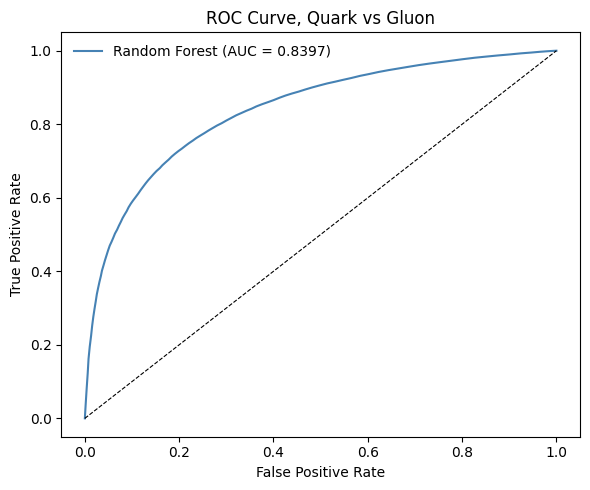

In [126]:
#roc curve for random forest
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(6, 5))

for clf, X_eval, label, color in [
    (rf,  X_test, 'Random Forest', 'steelblue')
    
]:
    scores = clf.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.4f})', color=color)

ax.plot([0,1],[0,1],'k--', lw=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve, Quark vs Gluon")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

AUC of 0.84 is reasonable for a 4-feature hand-crafted classifier. Literature benchmarks for quark/gluon tagging with full constituent-level information sit around 0.90, so we're not far off with just four aggregate observables. The curve rises steeply at low FPR which is the region that actually matters for physics analysis, keeping signal while rejecting most background.

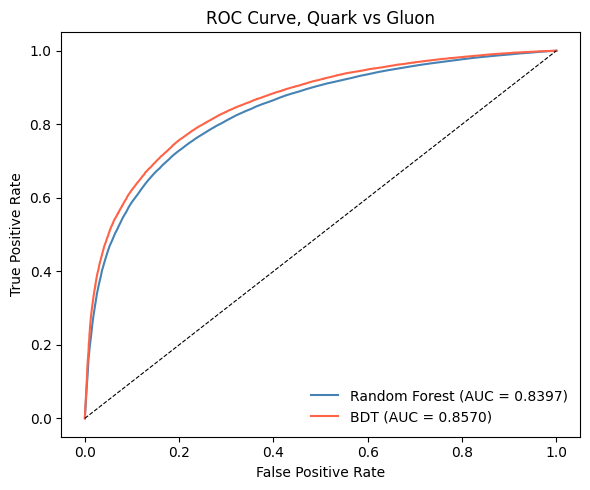

In [127]:
#roc plots for both bdt and random forest
fig, ax = plt.subplots(figsize=(6, 5))

for clf, X_eval, label, color in [
    (rf,  X_test, 'Random Forest', 'steelblue'),
    (bdt, X_test, 'BDT',           'tomato'),
]:
    scores = clf.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.4f})', color=color)

ax.plot([0,1],[0,1],'k--', lw=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve, Quark vs Gluon")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

BDT wins here, 0.857 vs 0.840 for RF. Boosting tends to do better when the classes overlap, which is exactly what's happening with quark/gluon jets in this feature space. Both curves look healthy at low FPR which is the region 
that actually matters if we're trying to keep signal in a real search.

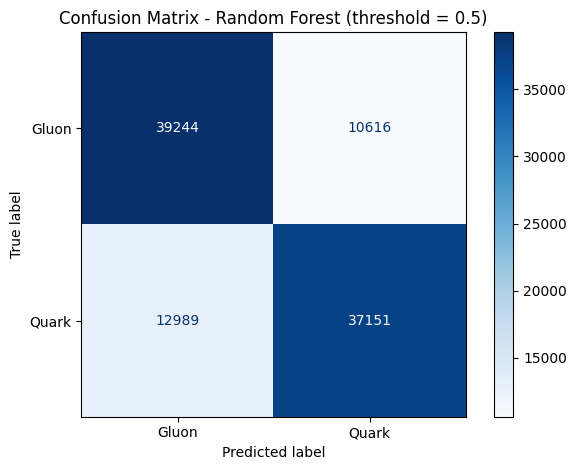

In [128]:
#confusion matrix #random

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred).astype(int)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Gluon', 'Quark'])
disp.plot(cmap='Blues')
for text in disp.ax_.texts:
    val = float(text.get_text())
    text.set_text(f'{int(val)}')
plt.title("Confusion Matrix - Random Forest (threshold = 0.5)")
plt.tight_layout()
plt.show()

At threshold 0.5, gluon rejection is slightly better than quark efficiency (39256 vs 37121 correct). The off-diagonal numbers are roughly symmetric (10-13k misclassified each way), hence the classifier isn't strongly biased toward either class. The 74% accuracy is consistent with the AUC, not perfect, but these are aggregate features, not the full constituent cloud.

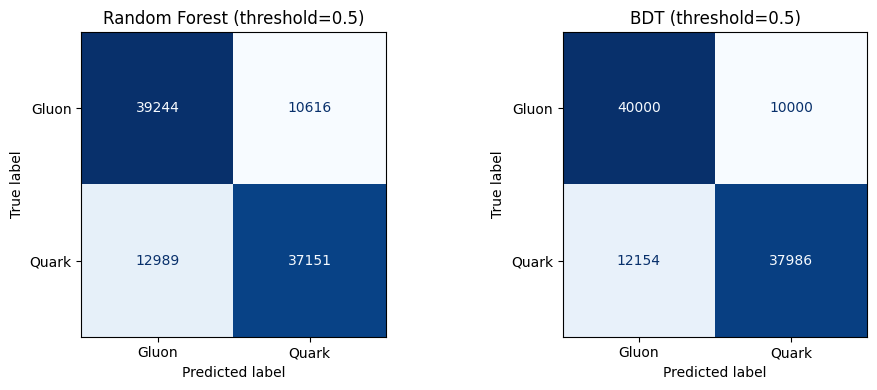

In [129]:
#confusion matrix comparing both bdt and random forest


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, clf, title in [
    (axes[0], rf,  'Random Forest'),
    (axes[1], bdt, 'BDT'),
]:
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred).astype(int)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Gluon','Quark'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    for text in ax.texts:
        val = float(text.get_text())
        text.set_text(f'{int(val)}')
    ax.set_title(f'{title} (threshold=0.5)')

plt.tight_layout()
plt.show()

BDT gets fewer quarks wrong (~12154 vs ~12989). Gluons are easier to tag correctly in both cases, probably because high-multiplicity jets are a pretty clean gluon signature, whereas quark jets at lower multiplicity look more like gluons.

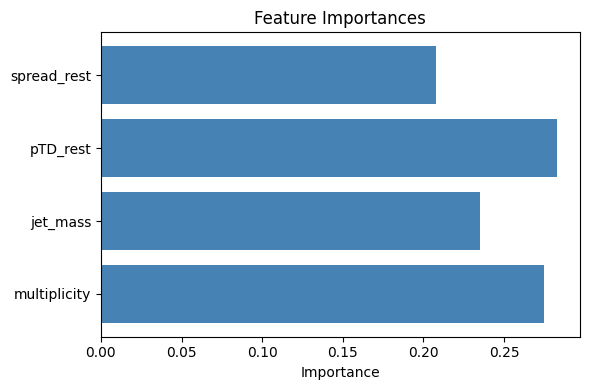

Most discriminating feature: pTD_rest


In [130]:
#feature
importances = rf.feature_importances_

plt.figure(figsize=(6, 4))
plt.barh(feature_names, importances, color='steelblue')
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

best_feature = feature_names[np.argmax(importances)]
print(f"Most discriminating feature: {best_feature}")

pTD in the rest frame comes out most discriminating, which makes sense, quark jets tend to have one hard core constituent dominating the pT sum, while gluon jets share it more democratically. Multiplicity is close behind, which was the expected result going in. Jet mass and spread contribute but less so, probably because they carry partially redundant information with pTD and multiplicity respectively.

Working in the rest frame seems to help for pTD and spread specifically, these measure the internal geometry of the jet, which is more natural in the frame where the jet isn't moving. Lab-frame pTD mixes the intrinsic momentum sharing with the jet's overall boost direction. Also, multiplicity and jet mass are Lorentz-invariant or boost-insensitive anyway, so for those two features the frame doesn't matter. Overall the rest frame is the right place to define isotropy-sensitive observables, even if the AUC gain over a pure lab-frame classifier would likely be modest.